# Joint Position & Velocity Error Tracking — `motion` vs `motiongg`

This notebook compares how closely the trained motions track their references using only:

- **Joint position RMSE** — radians
- **Joint velocity RMSE** — radians/second

`motion` = **DSMS**  
`motiongg` = **GhostGUI**

**Jerk/jitter tracking is intentionally excluded** because it is outside this project's scope.

Primary input:

`logs/dsms_analysis/all_trace_evaluation.csv`


In [1]:
import csv
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Configuration
# ---------------------------

CSV_PATH_OVERRIDE = None
RELATIVE_CSV_PATH = Path("logs/dsms_analysis/all_trace_evaluation.csv")
OUTPUT_DIR_NAME = "error_track_plots"

MOTION_CONDITION = "DSMS"  # motion
MOTIONGG_CONDITION = "GhostGUI"  # motiongg

POSITION_METRIC = "position_rmse_rad"
VELOCITY_METRIC = "velocity_rmse_rad_s"

PAIR_COLS = ["motion_base", "training_config", "checkpoint_iteration"]

In [2]:
def find_csv_path():
  if CSV_PATH_OVERRIDE is not None:
    path = Path(CSV_PATH_OVERRIDE).expanduser().resolve()
    if not path.exists():
      raise FileNotFoundError(f"CSV_PATH_OVERRIDE does not exist: {path}")
    return path

  cwd = Path.cwd().resolve()
  for root in [cwd, *cwd.parents]:
    candidate = root / RELATIVE_CSV_PATH
    if candidate.exists():
      return candidate

  raise FileNotFoundError(
    "Could not find logs/dsms_analysis/all_trace_evaluation.csv.\n"
    "Run this notebook from inside mjlab-trained, or set CSV_PATH_OVERRIDE."
  )


csv_path = find_csv_path()
output_dir = csv_path.parent / OUTPUT_DIR_NAME
output_dir.mkdir(parents=True, exist_ok=True)

print("Input :", csv_path)
print("Output:", output_dir)

Input : /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/all_trace_evaluation.csv
Output: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots


In [3]:
# ---------------------------
# Load CSV directly
# ---------------------------

with open(csv_path, "r", newline="") as f:
  reader = csv.DictReader(f)
  fieldnames = reader.fieldnames or []
  rows = list(reader)

required = {
  "condition",
  "training_config",
  "checkpoint_iteration",
  POSITION_METRIC,
  VELOCITY_METRIC,
}

missing = required - set(fieldnames)
if missing:
  raise ValueError(f"Missing required columns: {sorted(missing)}")

if "motion_base" not in fieldnames and "motion" not in fieldnames:
  raise ValueError("Need either 'motion_base' or 'motion' column.")


def to_float(value):
  try:
    return float(value)
  except (TypeError, ValueError):
    return math.nan


def get_motion_base(row):
  value = row.get("motion_base", "")
  if value:
    return value
  return row.get("motion", "")


track_rows = []
for row in rows:
  if row.get("condition") not in {MOTION_CONDITION, MOTIONGG_CONDITION}:
    continue

  pos = to_float(row.get(POSITION_METRIC))
  vel = to_float(row.get(VELOCITY_METRIC))

  if math.isnan(pos) or math.isnan(vel):
    continue

  track_rows.append(
    {
      "condition": row.get("condition", ""),
      "motion_base": get_motion_base(row),
      "training_config": row.get("training_config", ""),
      "checkpoint_iteration": to_float(row.get("checkpoint_iteration")),
      POSITION_METRIC: pos,
      VELOCITY_METRIC: vel,
    }
  )

print(f"Rows loaded: {len(rows)}")
print(f"Relevant DSMS/GhostGUI rows: {len(track_rows)}")
print(f"Motion bases: {len(set(r['motion_base'] for r in track_rows))}")

counts = defaultdict(lambda: defaultdict(int))
for r in track_rows:
  counts[r["motion_base"]][r["condition"]] += 1

print("\nRows per motion:")
for motion_name in sorted(counts):
  print(
    f"{motion_name:25s} "
    f"DSMS={counts[motion_name][MOTION_CONDITION]:3d}  "
    f"GhostGUI={counts[motion_name][MOTIONGG_CONDITION]:3d}"
  )

Rows loaded: 22
Relevant DSMS/GhostGUI rows: 22
Motion bases: 11

Rows per motion:
Crawlstand                DSMS=  3  GhostGUI=  1
Facedown                  DSMS=  1  GhostGUI=  1
Getup                     DSMS=  2  GhostGUI=  0
Kneel                     DSMS=  1  GhostGUI=  0
Lunges                    DSMS=  1  GhostGUI=  0
Lunges2                   DSMS=  2  GhostGUI=  1
Pushup                    DSMS=  1  GhostGUI=  1
Slidefloat                DSMS=  1  GhostGUI=  0
Squat                     DSMS=  1  GhostGUI=  1
Theworm                   DSMS=  1  GhostGUI=  1
Worm1                     DSMS=  1  GhostGUI=  1


## Pair matching

A `motion` and `motiongg` evaluation are compared only when these match exactly:

- motion
- training configuration
- checkpoint iteration

This avoids comparing unrelated checkpoints.


In [4]:
# ---------------------------
# Aggregate duplicate rows, then make exact pairs
# ---------------------------


def pair_key(row):
  ckpt = row["checkpoint_iteration"]
  if not math.isnan(ckpt):
    ckpt = int(ckpt)
  return (
    row["motion_base"],
    row["training_config"],
    ckpt,
  )


# Collect values by condition + exact pair key
grouped = defaultdict(
  lambda: {
    MOTION_CONDITION: {"pos": [], "vel": []},
    MOTIONGG_CONDITION: {"pos": [], "vel": []},
  }
)

for r in track_rows:
  key = pair_key(r)
  grouped[key][r["condition"]]["pos"].append(r[POSITION_METRIC])
  grouped[key][r["condition"]]["vel"].append(r[VELOCITY_METRIC])

paired = []
unmatched = []

for key in sorted(grouped, key=lambda x: (str(x[0]), str(x[1]), str(x[2]))):
  motion_base, training_config, checkpoint_iteration = key
  dsms = grouped[key][MOTION_CONDITION]
  gg = grouped[key][MOTIONGG_CONDITION]

  has_dsms = len(dsms["pos"]) > 0
  has_gg = len(gg["pos"]) > 0

  if not (has_dsms and has_gg):
    unmatched.append(
      {
        "motion_base": motion_base,
        "training_config": training_config,
        "checkpoint_iteration": checkpoint_iteration,
        "has_motion": has_dsms,
        "has_motiongg": has_gg,
      }
    )
    continue

  motion_pos = float(np.mean(dsms["pos"]))
  motion_vel = float(np.mean(dsms["vel"]))
  motiongg_pos = float(np.mean(gg["pos"]))
  motiongg_vel = float(np.mean(gg["vel"]))

  pos_delta = motion_pos - motiongg_pos
  vel_delta = motion_vel - motiongg_vel

  pos_pct = 100.0 * pos_delta / motiongg_pos if motiongg_pos != 0 else math.nan
  vel_pct = 100.0 * vel_delta / motiongg_vel if motiongg_vel != 0 else math.nan

  paired.append(
    {
      "motion_base": motion_base,
      "training_config": training_config,
      "checkpoint_iteration": checkpoint_iteration,
      "motion_position_rmse_rad": motion_pos,
      "motiongg_position_rmse_rad": motiongg_pos,
      "motion_velocity_rmse_rad_s": motion_vel,
      "motiongg_velocity_rmse_rad_s": motiongg_vel,
      "position_delta_rad": pos_delta,
      "velocity_delta_rad_s": vel_delta,
      "position_abs_difference_rad": abs(pos_delta),
      "velocity_abs_difference_rad_s": abs(vel_delta),
      "position_pct_change_vs_motiongg": pos_pct,
      "velocity_pct_change_vs_motiongg": vel_pct,
    }
  )

if not paired:
  raise ValueError("No exact motion vs motiongg pairs found.")

print(f"Exact matched pairs: {len(paired)}")
print(f"Unmatched entries: {len(unmatched)}")

if unmatched:
  print("\nUnmatched entries:")
  for item in unmatched:
    print(item)

Exact matched pairs: 7
Unmatched entries: 8

Unmatched entries:
{'motion_base': 'Crawlstand', 'training_config': 'Contact-rich', 'checkpoint_iteration': 30000, 'has_motion': True, 'has_motiongg': False}
{'motion_base': 'Crawlstand', 'training_config': 'Standard', 'checkpoint_iteration': 30000, 'has_motion': True, 'has_motiongg': False}
{'motion_base': 'Getup', 'training_config': 'Custom', 'checkpoint_iteration': 4500, 'has_motion': True, 'has_motiongg': False}
{'motion_base': 'Getup', 'training_config': 'Standard', 'checkpoint_iteration': 30000, 'has_motion': True, 'has_motiongg': False}
{'motion_base': 'Kneel', 'training_config': 'Standard', 'checkpoint_iteration': 20000, 'has_motion': True, 'has_motiongg': False}
{'motion_base': 'Lunges', 'training_config': 'Standard', 'checkpoint_iteration': 20000, 'has_motion': True, 'has_motiongg': False}
{'motion_base': 'Lunges2', 'training_config': 'Custom', 'checkpoint_iteration': 30000, 'has_motion': True, 'has_motiongg': False}
{'motion_base'

In [5]:
def format_checkpoint(x):
  if x is None or (isinstance(x, float) and math.isnan(x)):
    return "ckpt ?"
  x = int(x)
  if x >= 1000 and x % 1000 == 0:
    return f"{x // 1000}k"
  return str(x)


def make_label(row):
  return (
    f"{row['motion_base']} | "
    f"{row['training_config']} | "
    f"{format_checkpoint(row['checkpoint_iteration'])}"
  )


for row in paired:
  row["plot_label"] = make_label(row)

## 1. Joint position tracking error

Lower = closer to the reference joint positions.


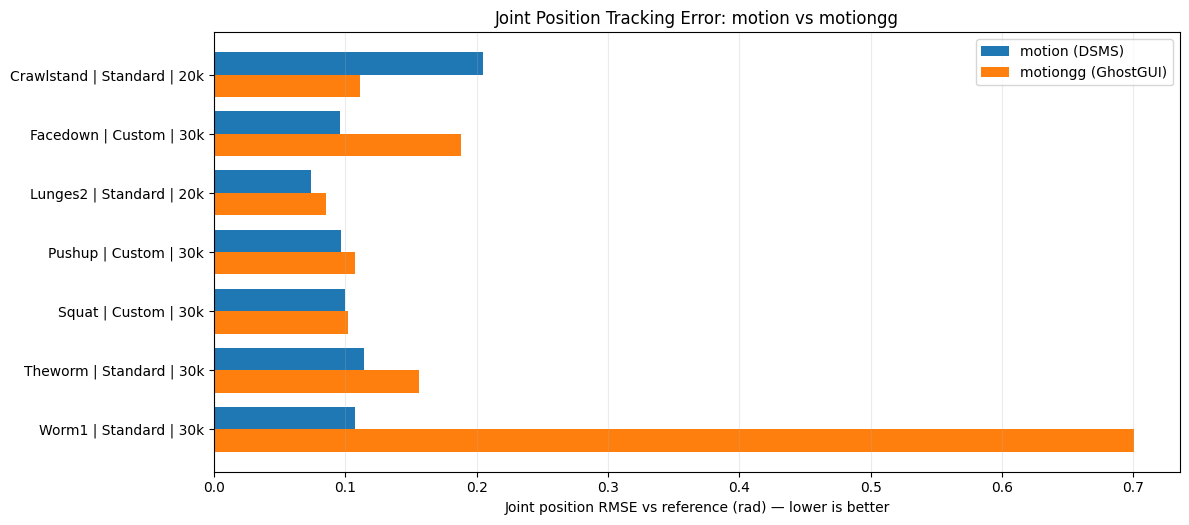

Saved: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots/position_error_motion_vs_motiongg.png


In [6]:
def plot_grouped_error(
  data,
  motion_col,
  motiongg_col,
  xlabel,
  title,
  filename,
):
  labels = [r["plot_label"] for r in data]
  motion_vals = [r[motion_col] for r in data]
  motiongg_vals = [r[motiongg_col] for r in data]

  y = np.arange(len(data))
  bar_h = 0.38
  fig_height = max(5, 0.55 * len(data) + 1.5)

  fig, ax = plt.subplots(figsize=(12, fig_height))
  ax.barh(y - bar_h / 2, motion_vals, height=bar_h, label="motion (DSMS)")
  ax.barh(y + bar_h / 2, motiongg_vals, height=bar_h, label="motiongg (GhostGUI)")

  ax.set_yticks(y)
  ax.set_yticklabels(labels)
  ax.invert_yaxis()
  ax.set_xlabel(xlabel)
  ax.set_title(title)
  ax.grid(axis="x", alpha=0.25)
  ax.legend()

  fig.tight_layout()
  save_path = output_dir / filename
  fig.savefig(save_path, dpi=220, bbox_inches="tight")
  plt.show()

  print("Saved:", save_path)


plot_grouped_error(
  paired,
  "motion_position_rmse_rad",
  "motiongg_position_rmse_rad",
  "Joint position RMSE vs reference (rad) — lower is better",
  "Joint Position Tracking Error: motion vs motiongg",
  "position_error_motion_vs_motiongg.png",
)

## 2. Joint velocity tracking error

Lower = closer to the reference joint velocities.


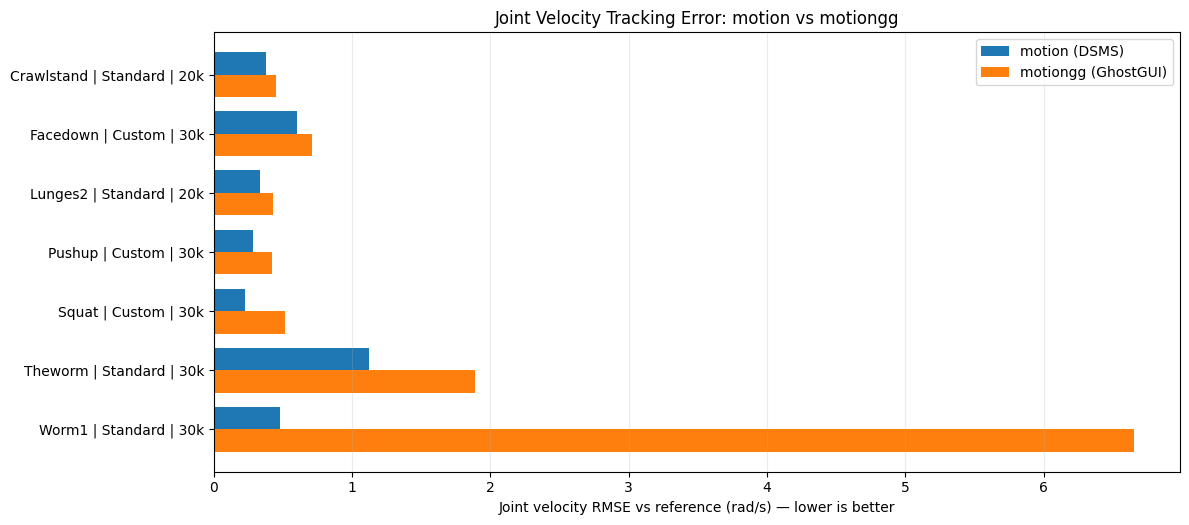

Saved: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots/velocity_error_motion_vs_motiongg.png


In [7]:
plot_grouped_error(
  paired,
  "motion_velocity_rmse_rad_s",
  "motiongg_velocity_rmse_rad_s",
  "Joint velocity RMSE vs reference (rad/s) — lower is better",
  "Joint Velocity Tracking Error: motion vs motiongg",
  "velocity_error_motion_vs_motiongg.png",
)

## 3. Error difference: `motion - motiongg`

\[
\Delta e = e_{motion} - e_{motiongg}
\]

- Negative → `motion` has less tracking error
- Positive → `motiongg` has less tracking error
- Near zero → similar reference tracking


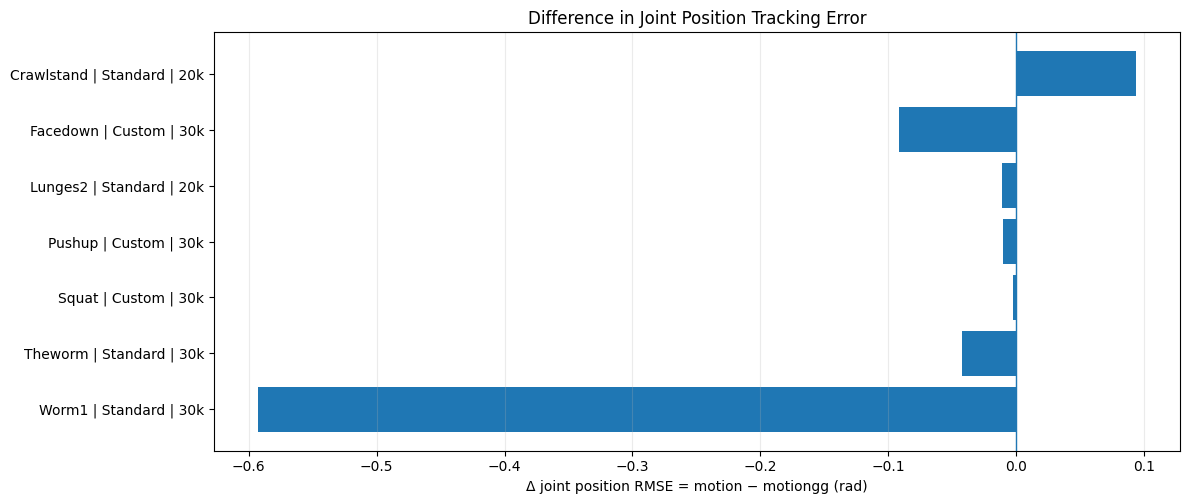

Saved: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots/position_error_difference_motion_minus_motiongg.png


In [8]:
def plot_error_difference(data, delta_col, xlabel, title, filename):
  labels = [r["plot_label"] for r in data]
  values = [r[delta_col] for r in data]

  y = np.arange(len(data))
  fig_height = max(5, 0.52 * len(data) + 1.5)

  fig, ax = plt.subplots(figsize=(12, fig_height))
  ax.barh(y, values)
  ax.axvline(0.0, linewidth=1)

  ax.set_yticks(y)
  ax.set_yticklabels(labels)
  ax.invert_yaxis()
  ax.set_xlabel(xlabel)
  ax.set_title(title)
  ax.grid(axis="x", alpha=0.25)

  fig.tight_layout()
  save_path = output_dir / filename
  fig.savefig(save_path, dpi=220, bbox_inches="tight")
  plt.show()

  print("Saved:", save_path)


plot_error_difference(
  paired,
  "position_delta_rad",
  "Δ joint position RMSE = motion − motiongg (rad)",
  "Difference in Joint Position Tracking Error",
  "position_error_difference_motion_minus_motiongg.png",
)

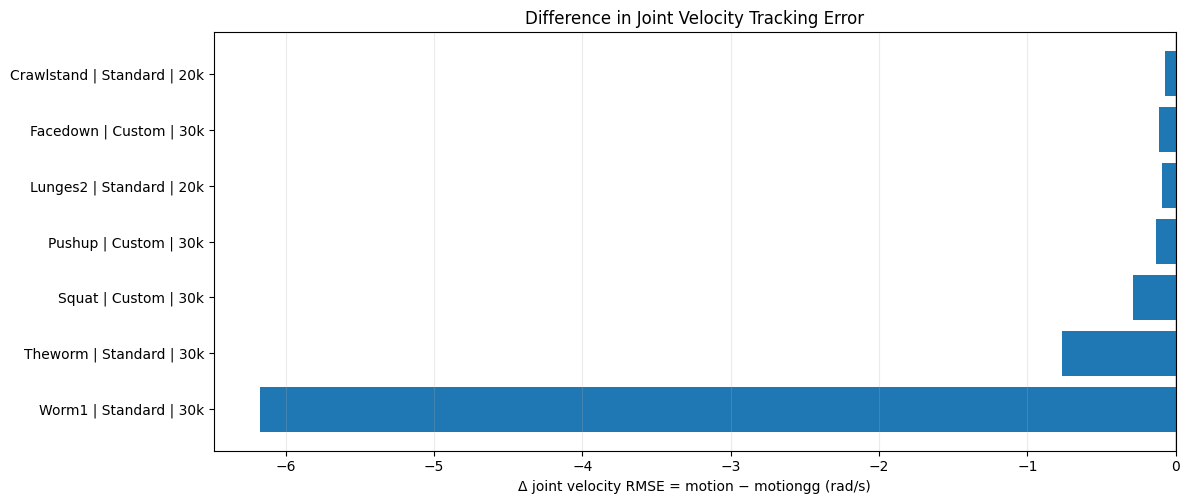

Saved: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots/velocity_error_difference_motion_minus_motiongg.png


In [9]:
plot_error_difference(
  paired,
  "velocity_delta_rad_s",
  "Δ joint velocity RMSE = motion − motiongg (rad/s)",
  "Difference in Joint Velocity Tracking Error",
  "velocity_error_difference_motion_minus_motiongg.png",
)

## 4. Numerical comparison table

This prints and exports the exact paired comparison.


In [10]:
summary_fields = [
  "motion_base",
  "training_config",
  "checkpoint_iteration",
  "motion_position_rmse_rad",
  "motiongg_position_rmse_rad",
  "position_abs_difference_rad",
  "position_delta_rad",
  "position_pct_change_vs_motiongg",
  "motion_velocity_rmse_rad_s",
  "motiongg_velocity_rmse_rad_s",
  "velocity_abs_difference_rad_s",
  "velocity_delta_rad_s",
  "velocity_pct_change_vs_motiongg",
]

header = (
  f"{'motion':18s} {'config':22s} {'ckpt':>8s} "
  f"{'pos_m':>10s} {'pos_gg':>10s} {'Δpos':>10s} "
  f"{'vel_m':>10s} {'vel_gg':>10s} {'Δvel':>10s}"
)

print(header)
print("-" * len(header))

for r in paired:
  print(
    f"{r['motion_base'][:18]:18s} "
    f"{r['training_config'][:22]:22s} "
    f"{str(r['checkpoint_iteration']):>8s} "
    f"{r['motion_position_rmse_rad']:10.4f} "
    f"{r['motiongg_position_rmse_rad']:10.4f} "
    f"{r['position_delta_rad']:10.4f} "
    f"{r['motion_velocity_rmse_rad_s']:10.4f} "
    f"{r['motiongg_velocity_rmse_rad_s']:10.4f} "
    f"{r['velocity_delta_rad_s']:10.4f}"
  )

summary_path = output_dir / "paired_position_velocity_error_summary.csv"

with open(summary_path, "w", newline="") as f:
  writer = csv.DictWriter(f, fieldnames=summary_fields)
  writer.writeheader()
  for r in paired:
    writer.writerow({key: r[key] for key in summary_fields})

print("\nSaved:", summary_path)

motion             config                     ckpt      pos_m     pos_gg       Δpos      vel_m     vel_gg       Δvel
--------------------------------------------------------------------------------------------------------------------
Crawlstand         Standard                  20000     0.2048     0.1111     0.0936     0.3784     0.4477    -0.0692
Facedown           Custom                    30000     0.0960     0.1880    -0.0919     0.5986     0.7129    -0.1143
Lunges2            Standard                  20000     0.0743     0.0855    -0.0112     0.3326     0.4252    -0.0926
Pushup             Custom                    30000     0.0967     0.1071    -0.0104     0.2836     0.4189    -0.1353
Squat              Custom                    30000     0.0997     0.1022    -0.0025     0.2259     0.5150    -0.2891
Theworm            Standard                  30000     0.1142     0.1564    -0.0422     1.1191     1.8877    -0.7686
Worm1              Standard                  30000     0.1075   

## 5. One result per motion

If a motion has multiple matched checkpoints/configurations, this section averages those matched results to create one clean comparison per motion.


In [11]:
motion_groups = defaultdict(list)

for r in paired:
  motion_groups[r["motion_base"]].append(r)

motion_level = []

for motion_name in sorted(motion_groups):
  group = motion_groups[motion_name]

  motion_level.append(
    {
      "motion_base": motion_name,
      "motion_position_rmse_rad": float(
        np.mean([r["motion_position_rmse_rad"] for r in group])
      ),
      "motiongg_position_rmse_rad": float(
        np.mean([r["motiongg_position_rmse_rad"] for r in group])
      ),
      "motion_velocity_rmse_rad_s": float(
        np.mean([r["motion_velocity_rmse_rad_s"] for r in group])
      ),
      "motiongg_velocity_rmse_rad_s": float(
        np.mean([r["motiongg_velocity_rmse_rad_s"] for r in group])
      ),
      "matched_evaluations": len(group),
      "plot_label": motion_name,
    }
  )

print(
  f"{'motion':22s} {'N':>4s} "
  f"{'pos motion':>12s} {'pos motiongg':>14s} "
  f"{'vel motion':>12s} {'vel motiongg':>14s}"
)
print("-" * 84)

for r in motion_level:
  print(
    f"{r['motion_base'][:22]:22s} "
    f"{r['matched_evaluations']:4d} "
    f"{r['motion_position_rmse_rad']:12.4f} "
    f"{r['motiongg_position_rmse_rad']:14.4f} "
    f"{r['motion_velocity_rmse_rad_s']:12.4f} "
    f"{r['motiongg_velocity_rmse_rad_s']:14.4f}"
  )

motion                    N   pos motion   pos motiongg   vel motion   vel motiongg
------------------------------------------------------------------------------------
Crawlstand                1       0.2048         0.1111       0.3784         0.4477
Facedown                  1       0.0960         0.1880       0.5986         0.7129
Lunges2                   1       0.0743         0.0855       0.3326         0.4252
Pushup                    1       0.0967         0.1071       0.2836         0.4189
Squat                     1       0.0997         0.1022       0.2259         0.5150
Theworm                   1       0.1142         0.1564       1.1191         1.8877
Worm1                     1       0.1075         0.7004       0.4752         6.6525


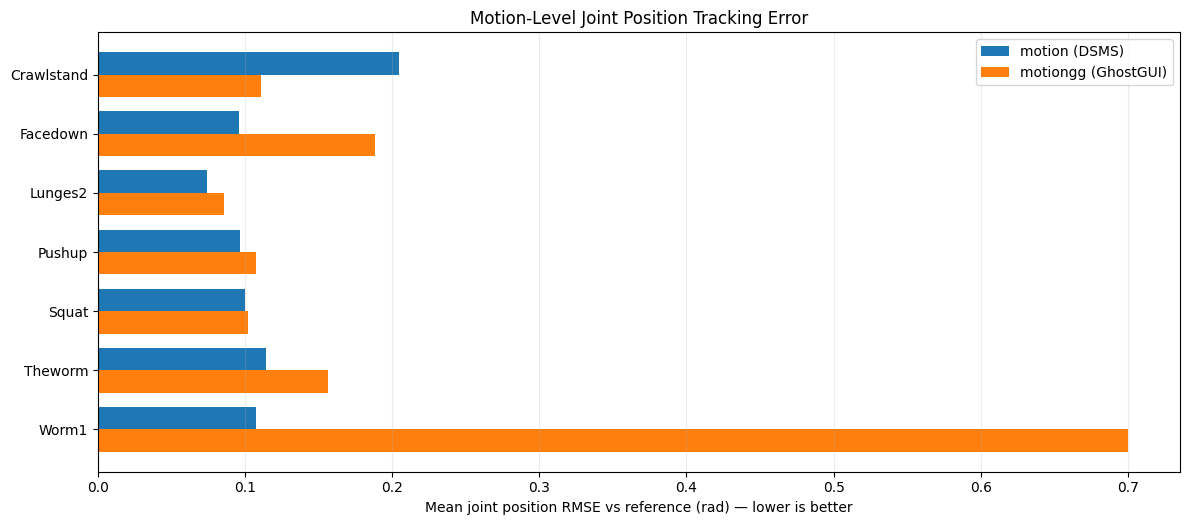

Saved: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots/motion_level_position_error.png


In [12]:
plot_grouped_error(
  motion_level,
  "motion_position_rmse_rad",
  "motiongg_position_rmse_rad",
  "Mean joint position RMSE vs reference (rad) — lower is better",
  "Motion-Level Joint Position Tracking Error",
  "motion_level_position_error.png",
)

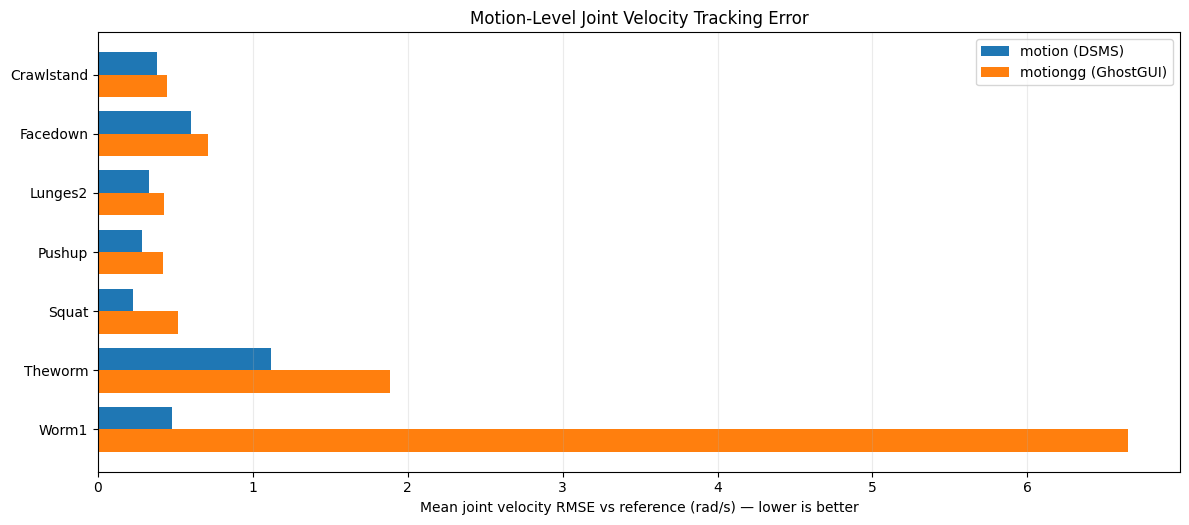

Saved: /Users/yitxuenglim/Downloads/mjlab-trained/logs/dsms_analysis/error_track_plots/motion_level_velocity_error.png


In [13]:
plot_grouped_error(
  motion_level,
  "motion_velocity_rmse_rad_s",
  "motiongg_velocity_rmse_rad_s",
  "Mean joint velocity RMSE vs reference (rad/s) — lower is better",
  "Motion-Level Joint Velocity Tracking Error",
  "motion_level_velocity_error.png",
)

## Interpretation

The study question here is:

> How much does each learned motion deviate from its own reference, and does that deviation differ between `motion` and `motiongg`?

Use:

- **position RMSE** → joint-angle tracking quality
- **velocity RMSE** → joint-motion-rate tracking quality

Smaller is better.

Jerk/jitter is not analyzed in this notebook.
